<a href="https://colab.research.google.com/github/xieryn/Assign_1/blob/main/DATA_VISUALIZATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>What Is Data Visualization?</h1>
<hr>
<h3>“The representation of information in the form of a chart, diagram, picture, etc.”</h3>

<h6>
Use a simple bar chart showing the number of accidents per year (2019–2022) to illustrate how raw numbers become instantly understandable when visualized.
</h6>

In [ ]:
import pandas as pd
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
df = pd.read_csv('datasets\\accident_data.csv')

In [ ]:
# Step 1: Convert to string only if not null
df['Accident Date'] = df['Accident Date'].astype(str)
# Step 2: Replace '/' with '-' safely
df['Accident Date'] = df['Accident Date'].apply(lambda x: x.replace('/', '-') if pd.notnull(x) else x)
# Step 3: Strip whitespace
df['Accident Date'] = df['Accident Date'].apply(lambda x: x.strip() if pd.notnull(x) else x)
# Step 4: Convert to datetime
df['Accident Date'] = pd.to_datetime(df['Accident Date'], dayfirst=True, errors='coerce')


df['Latitude'] = df['Latitude'].fillna(df['Latitude'].mode()[0])
df['Longitude'] = df['Longitude'].fillna(df['Longitude'].mode()[0])
df['Road_Surface_Conditions'] = df['Road_Surface_Conditions'].fillna('unaccounted')
df['Road_Type'] = df['Road_Type'].fillna('unaccounted')
df['Weather_Conditions'] = df['Weather_Conditions'].fillna('unaccounted_weather_condition')
df['Urban_or_Rural_Area'] = df['Urban_or_Rural_Area'].fillna('unknown_area')
df.dtypes
df.isnull().sum()

df['Year'] = df['Accident Date'].dt.year
df['Month'] =  df['Accident Date'].dt.month
df['Day'] =  df['Accident Date'].dt.day
df['DayOfWeek'] =  df['Accident Date'].dt.dayofweek
df.isnull().sum()

Index                      0
Accident_Severity          0
Accident Date              0
Latitude                   0
Light_Conditions           0
District Area              0
Longitude                  0
Number_of_Casualties       0
Number_of_Vehicles         0
Road_Surface_Conditions    0
Road_Type                  0
Urban_or_Rural_Area        0
Weather_Conditions         0
Vehicle_Type               0
Year                       0
Month                      0
Day                        0
DayOfWeek                  0
dtype: int64

<h2>Replacing Day using LOC</h2>
<h4>To Replace 'Day' Column instead of just numbers to replace it with 'Week Day' and 'Weekend', by referring to 'Day of Week' if the Number
is 4, 5, 6 Friday to Sunday</h4>

In [ ]:
# FIRST: Assume ALL days are Weekdays
df['Day'] = 'Weekday'
# SECOND: Change ONLY Saturday (5) and Sunday (6) to Weekend
df.loc[df['DayOfWeek'].isin([4, 5, 6]), 'Day'] = 'Weekend'

In [ ]:
df.dtypes

Index                              object
Accident_Severity                  object
Accident Date              datetime64[ns]
Latitude                          float64
Light_Conditions                   object
District Area                      object
Longitude                         float64
Number_of_Casualties                int64
Number_of_Vehicles                  int64
Road_Surface_Conditions            object
Road_Type                          object
Urban_or_Rural_Area                object
Weather_Conditions                 object
Vehicle_Type                       object
Year                                int32
Month                               int32
Day                                object
DayOfWeek                           int32
dtype: object

<h4>** NOTE -> Before Changing Data Type Make sure you have already filled the Null Values, Other wise it would result to an error</h4>

In [ ]:
df['Index'] = df['Index'].astype('str')
df['Accident_Severity'] = df['Accident_Severity'].astype('category')
df['Light_Conditions'] = df['Light_Conditions'].astype('category')
df['District Area'] = df['District Area'].astype('category')
df['Road_Surface_Conditions'] = df['Road_Surface_Conditions'].astype('category')
df['Road_Type'] = df['Road_Type'].astype('category')
df['Urban_or_Rural_Area'] = df['Urban_or_Rural_Area'].astype('category')
df['Weather_Conditions'] = df['Weather_Conditions'].astype('category')
df['Vehicle_Type'] = df['Vehicle_Type'].astype('category')
df['Day'] = df['Day'].astype('category')

In [ ]:
df['Day'].value_counts()

Day
Weekday    366299
Weekend    294380
Name: count, dtype: int64

In [ ]:
#df.to_csv('uk_accident_cleaned.csv',index=False)

<Axes: xlabel='Year'>

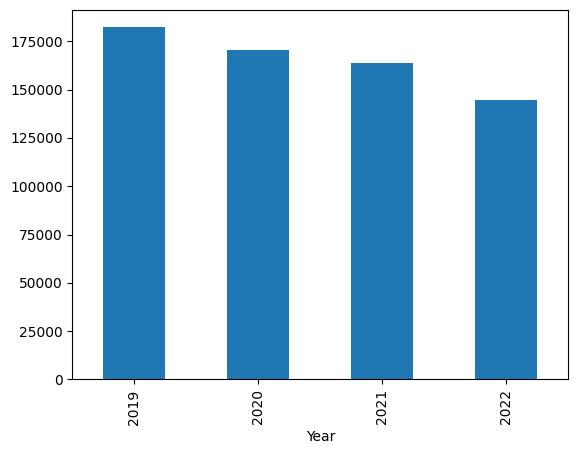

In [ ]:
# Example: Bar chart of accident counts per year
import matplotlib.pyplot as plt
df.groupby('Year')['Index'].count().plot(kind='bar')

<h1>Why Is It Important?</h1>
<ul>
    <li><h4>Helps identify patterns, trends, and outliers.</h4> </li>
    <li><h4>Speeds up decision-making.</h4></li>
    <li><h4>Makes data accessible to non-technical stakeholders.</h4></li>
</ul>

<h4>
📊 Example Visualization: Line chart showing monthly accident trends over time. This reveals seasonal spikes (e.g., winter months, holidays).
</h4>

<table>
<tr>
<th>Visualization Type</th>
<th>UK Dataset Example (Using YOUR Columns)</th>
<th>Purpose</th>
</tr>
<tr>
<td>Histogram</td>
<td>Distribution of <code>Number_of_Casualties</code></td>
<td>Show how many accidents have 1, 2, 3+ casualties (most have 1)</td>
</tr>
<tr>
<td>Heatmap</td>
<td>Accidents by <code>Month</code> vs. <code>DayOfWeek</code></td>
<td>Reveal seasonal patterns and weekday/weekend differences</td>
</tr>
<tr>
<td>Box Plot</td>
<td><code>Number_of_Casualties</code> by <code>Urban_or_Rural_Area</code></td>
<td>Compare casualty severity between urban and rural areas</td>
</tr>
<tr>
<td>Pie Chart</td>
<td>Proportions of <code>Accident_Severity</code> (Slight/Serious/Fatal)</td>
<td>Show that ~90% of accidents are "Slight" (surprising insight!)</td>
</tr>
<tr>
<td>Stacked Bar Chart</td>
<td><code>Road_Type</code> vs. <code>Accident_Severity</code></td>
<td>Compare which road types have higher proportions of serious/fatal accidents</td>
</tr>
</table>

<h1>Univariate Plotting </h1>
<h2>Focus on one variable at a time.</h2>

<h4>📌 Example: Histogram of vehicle types involved </h4>


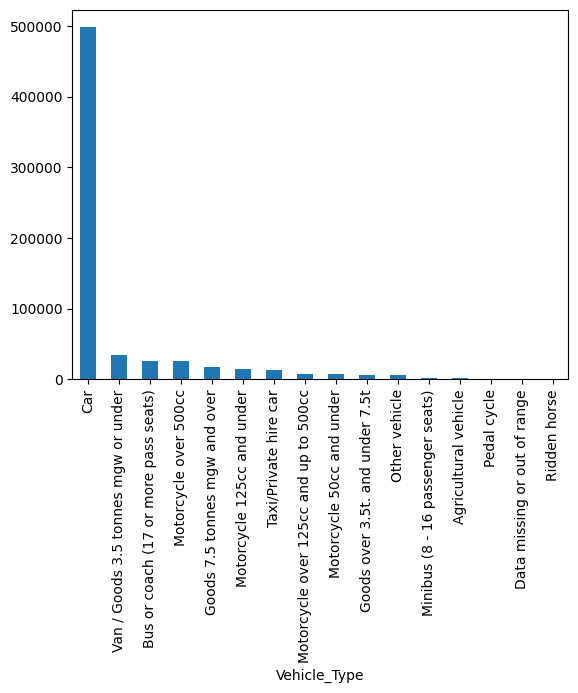

In [ ]:

df['Vehicle_Type'].value_counts().plot(kind='bar')
plt.show()

In [ ]:
nocar_df = df[df['Vehicle_Type'] != 'Car']
# nocar_df

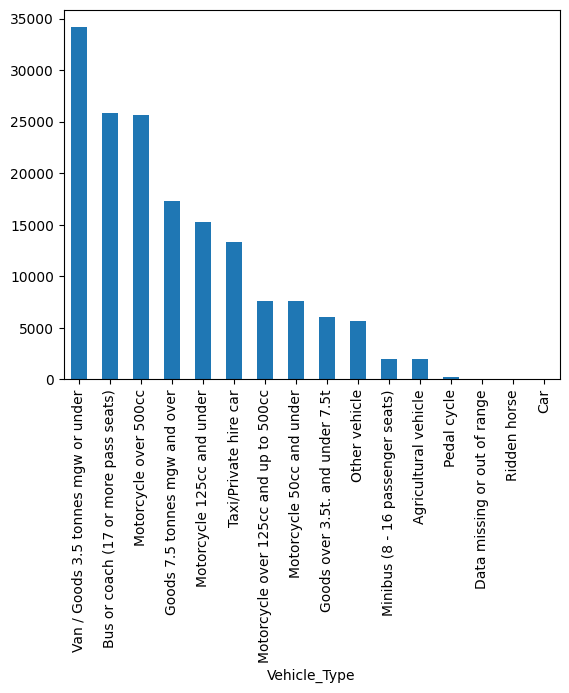

In [ ]:
nocar_df['Vehicle_Type'].value_counts().plot(kind='bar')
plt.show()

<h1> <i>A Data Analysis Journey: From National Trends to Local Insights </i></h1>

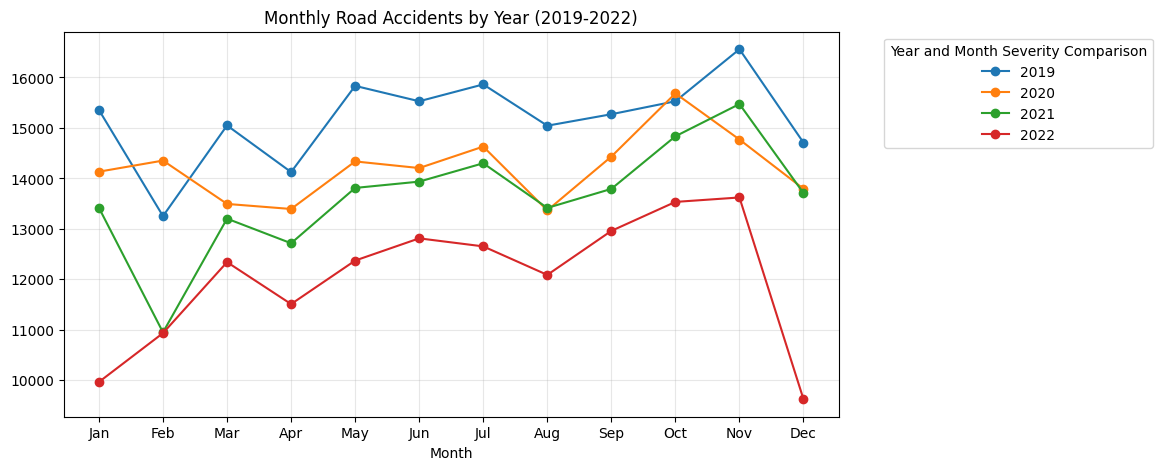

In [ ]:
import matplotlib.pyplot as plt

# 1. Group by Year FIRST, then Month (critical order!)
monthly_data = df.groupby(['Year', 'Month']).size()

# 2. Unstack Year to create separate lines for each year
monthly_data = monthly_data.unstack(level=0)

# 3. Plot with clean formatting (only 4 lines!)
monthly_data.plot(
    marker='o',
    figsize=(10, 5),
    title='Monthly Road Accidents by Year (2019-2022)'
)
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend(title='Year and Month Severity Comparison', bbox_to_anchor = (1.05,1), loc='upper left')
plt.grid(alpha=0.3)
plt.show()

<h1>Correlational Analysis</h1>
<hr>

<h3>Numeric Values Correlation </h3>

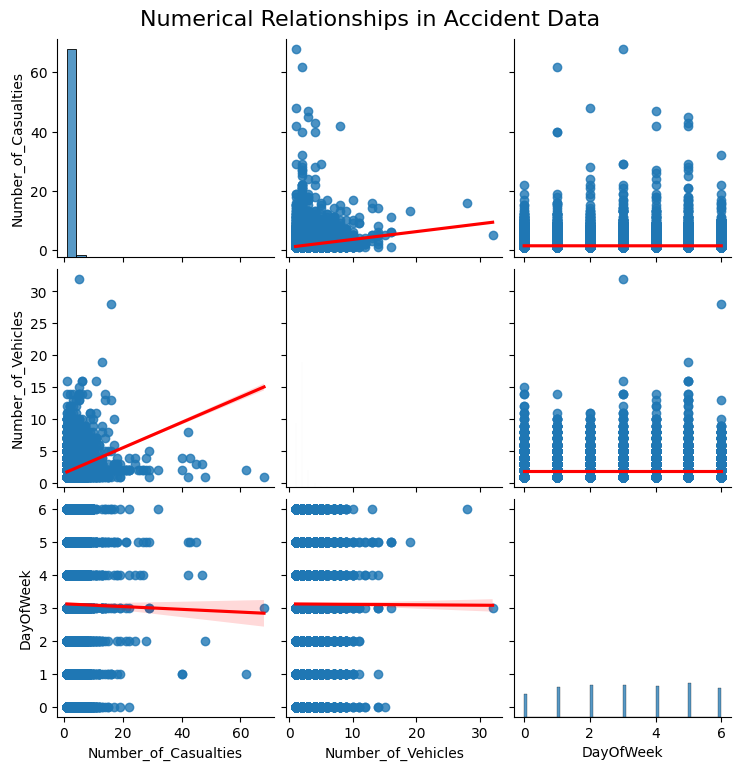

In [ ]:
sns.pairplot(
    df[['Number_of_Casualties', 'Number_of_Vehicles', 'DayOfWeek']],
    kind='reg',
    plot_kws={'line_kws': {'color': 'red'}}  # Makes trend lines red
)
plt.suptitle('Numerical Relationships in Accident Data', y=1.02, fontsize=16)
plt.show()

<h3>Categorical Data Correlational Analysis </h3>
<hr>

In [ ]:
# Create a copy to avoid changing original data
corr_df = df.copy()

# Convert Accident_Severity to numerical (1=Slight, 2=Serious, 3=Fatal)
severity_map = {'Slight': 1, 'Serious': 2, 'Fatal': 3}
corr_df['Severity_Num'] = corr_df['Accident_Severity'].map(severity_map)

# Convert Urban_or_Rural_Area to numerical (1=Urban, 0=Rural)
area_map = {'Urban': 1, 'Rural': 0}
corr_df['Area_Num'] = corr_df['Urban_or_Rural_Area'].map(area_map)

# Convert Weather_Conditions to risk level (simplified)
weather_map = {
    'Fine no high winds': 1,
    'Raining no high winds': 2,
    'Snowing no high winds': 3,
    'Fog or mist': 2,
    'Other': 2
}
corr_df['Weather_Risk'] = corr_df['Weather_Conditions'].map(weather_map).fillna(1)

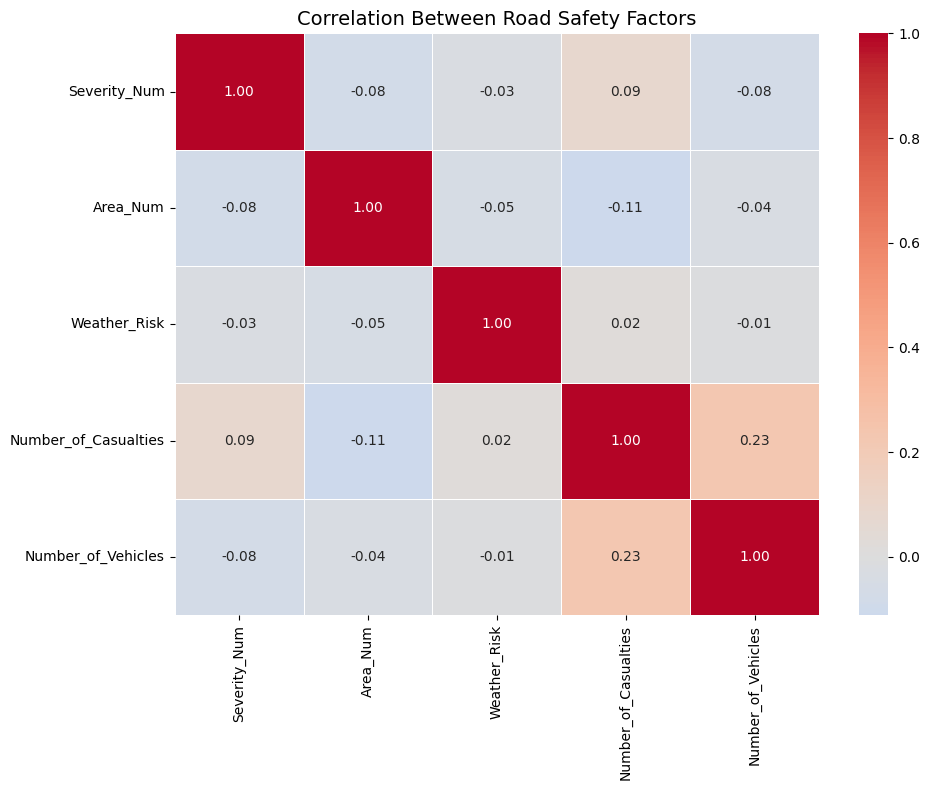

In [ ]:
# Calculate correlations between our numerical variables
correlation_matrix = corr_df[['Severity_Num', 'Area_Num', 'Weather_Risk',
                             'Number_of_Casualties', 'Number_of_Vehicles']].corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,        # Show correlation values
    fmt=".2f",         # Format to 2 decimal places
    cmap='coolwarm',   # Blue=negative, Red=positive
    center=0,          # Center at 0 correlation
    linewidths=0.5
)

plt.title('Correlation Between Road Safety Factors', fontsize=14)
plt.tight_layout()
plt.show()

<h2><i>Seasonal Analysis </i></h2>

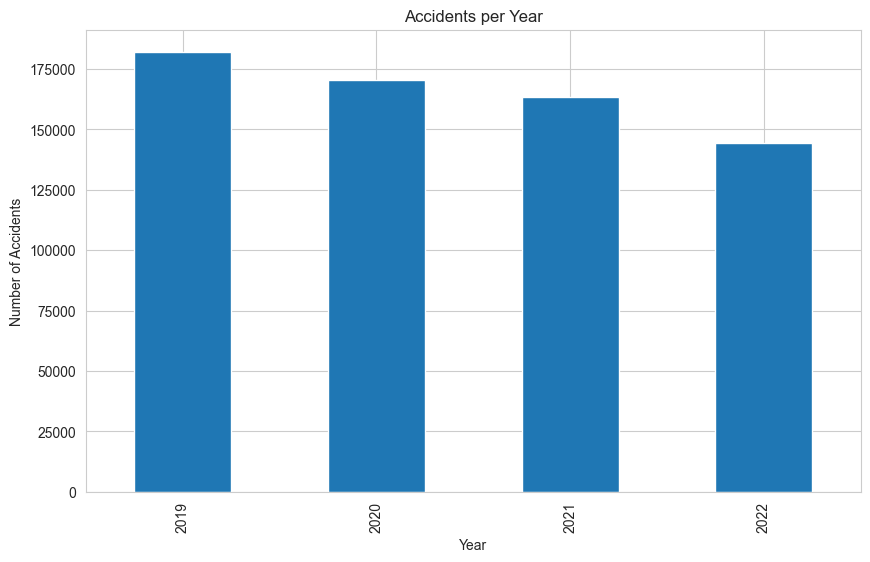

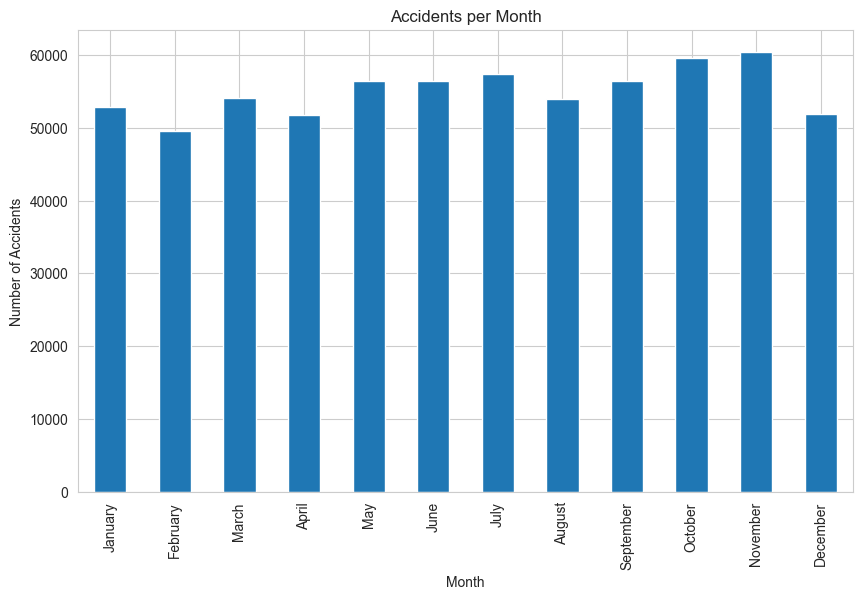

DayOfWeek
Monday        72680
Tuesday       94550
Wednesday     99558
Thursday      99511
Friday        97900
Saturday     107178
Sunday        89302
Name: count, dtype: int64


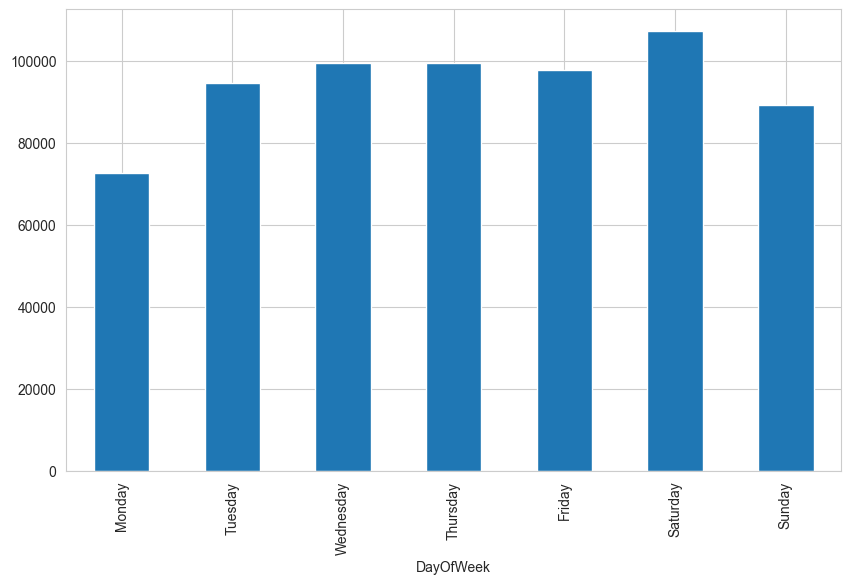

In [ ]:
# Accidents per year
accidents_per_year = df['Year'].value_counts().sort_index()
accidents_per_month = df['Month'].value_counts().sort_index()
accidents_per_day = df['DayOfWeek'].value_counts().sort_index()


#PER YEAR
accidents_per_year.plot(kind='bar')
plt.title('Accidents per Year')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.show()

month_names = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}

# Replace numerical months with their names
accidents_per_month.index = accidents_per_month.index.map(month_names)


accidents_per_month.plot(kind='bar')
plt.title('Accidents per Month')
plt.xlabel('Month')
plt.ylabel('Number of Accidents')
plt.show()


#accident per day
day_names = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}

accidents_per_day.index = accidents_per_day.index.map(day_names)
accidents_per_day.plot(kind='bar')
print(accidents_per_day)

<h3>Accident Severity </h3>

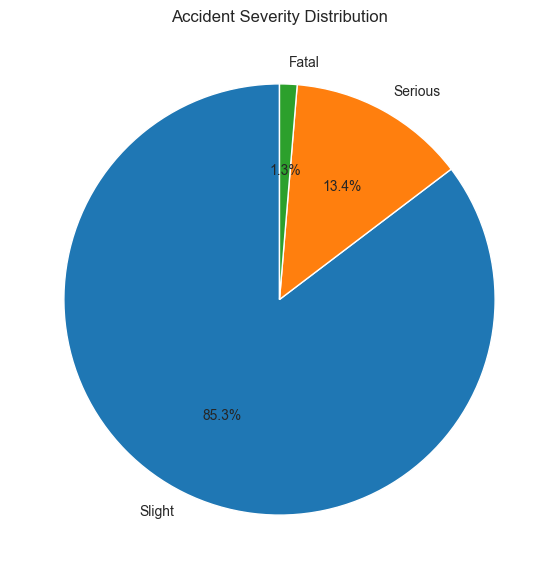

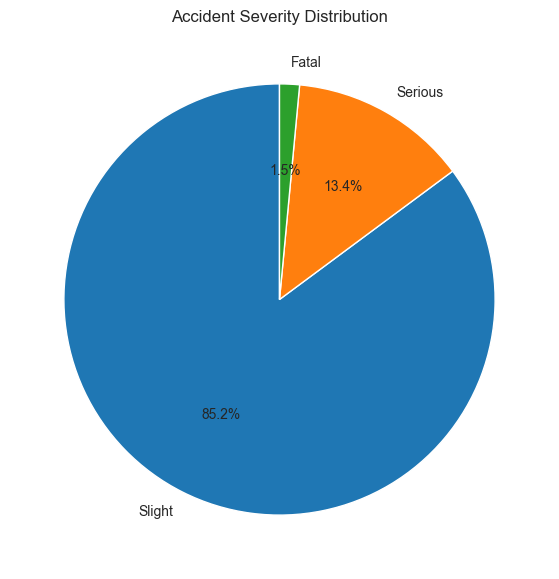

In [ ]:
severity_counts = df['Accident_Severity'].value_counts()

plt.pie(severity_counts,
        labels = severity_counts.index,
        autopct = '%1.1f%%',
        startangle = 90)
plt.gcf().set_size_inches(10,7)
plt.title('Accident Severity Distribution')
plt.show()

severity_2019 = df[df['Year'] == 2019]
# severity_2019
sc_2019 = severity_2019['Accident_Severity'].value_counts()

plt.pie(sc_2019,
        labels = sc_2019.index,
        autopct = '%1.1f%%',
        startangle = 90)
plt.gcf().set_size_inches(10,7)
plt.title('Accident Severity Distribution')
plt.show()


<h1>TASK STUDENT TO SELECT 6 to 7 DISTRICT AMONGST THE DISTRICT AREA AND APPLY SPECIFIC ANALYSIS </h1>

<h1>Using District Area to make a comparison to a general result </h1>
<h3>London Analysis</h3>
<hr>
<br>
<img src='https://images.pexels.com/photos/258117/pexels-photo-258117.jpeg?cs=srgb&dl=pexels-pixabay-258117.jpg&fm=jpg'>

In [ ]:
# df.dtypes
london_df = df[df['District Area'] == 'City of London']

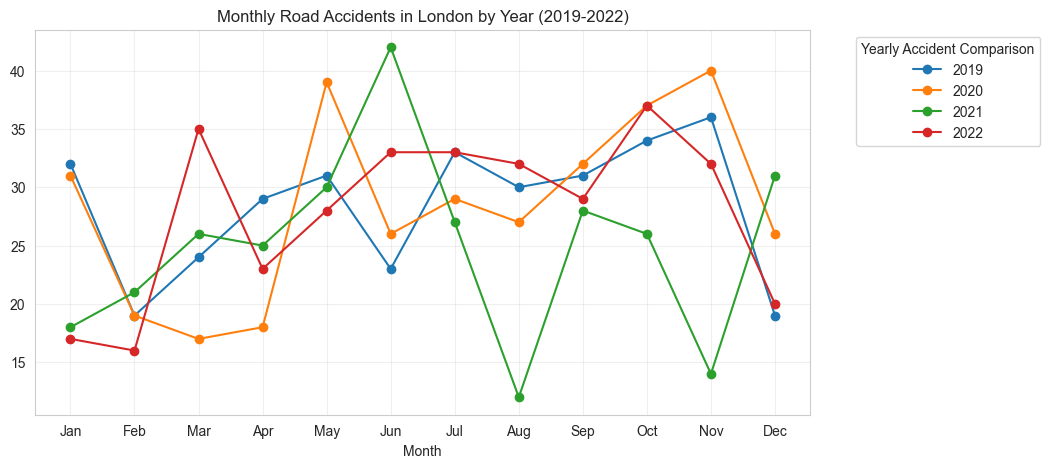

In [ ]:
monthly_londondata = london_df.groupby(['Year', 'Month']).size()

monthly_londondata = monthly_londondata.unstack(level=0)

monthly_londondata.plot(
    marker='o',
    figsize=(10, 5),
    title='Monthly Road Accidents in London by Year (2019-2022)'
)
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend(title='Yearly Accident Comparison', bbox_to_anchor = (1.05,1), loc='upper left')
plt.grid(alpha=0.3)
plt.show()

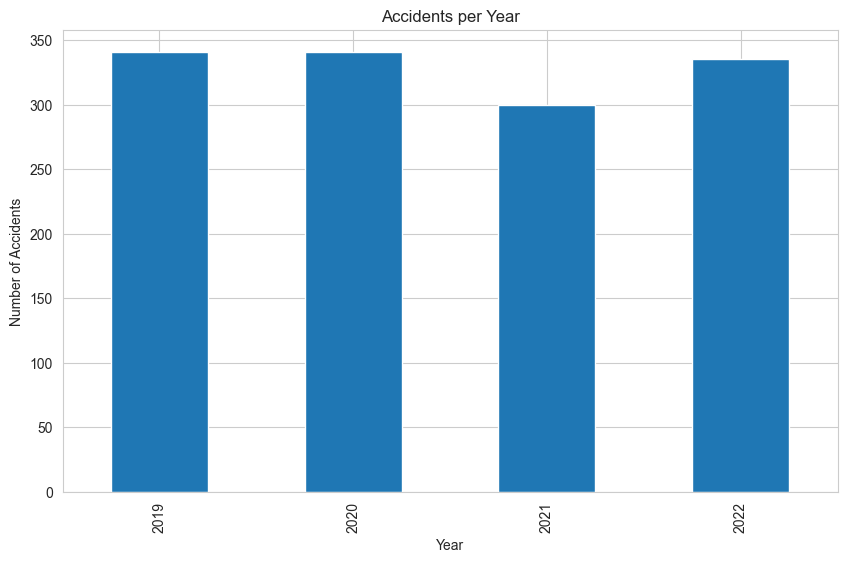

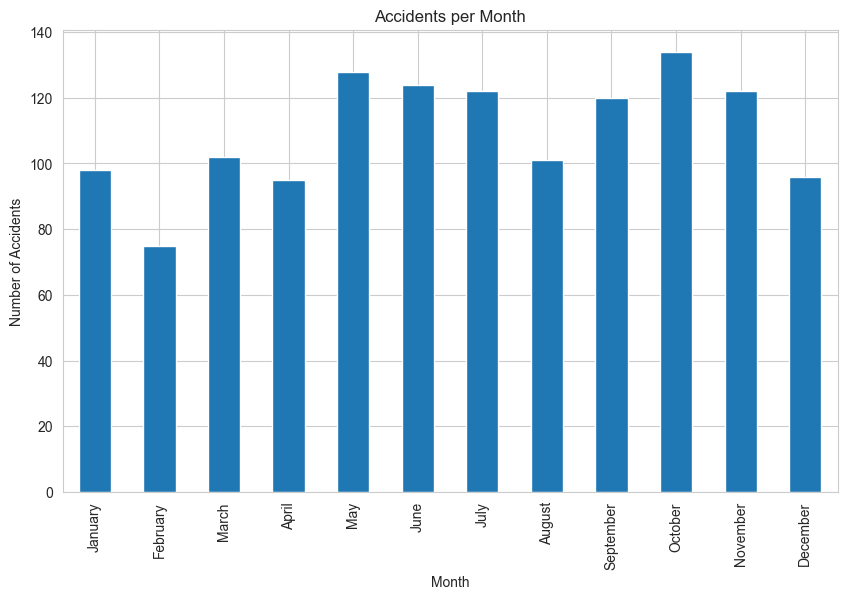

DayOfWeek
Monday        65
Tuesday      198
Wednesday    245
Thursday     244
Friday       249
Saturday     236
Sunday        80
Name: count, dtype: int64


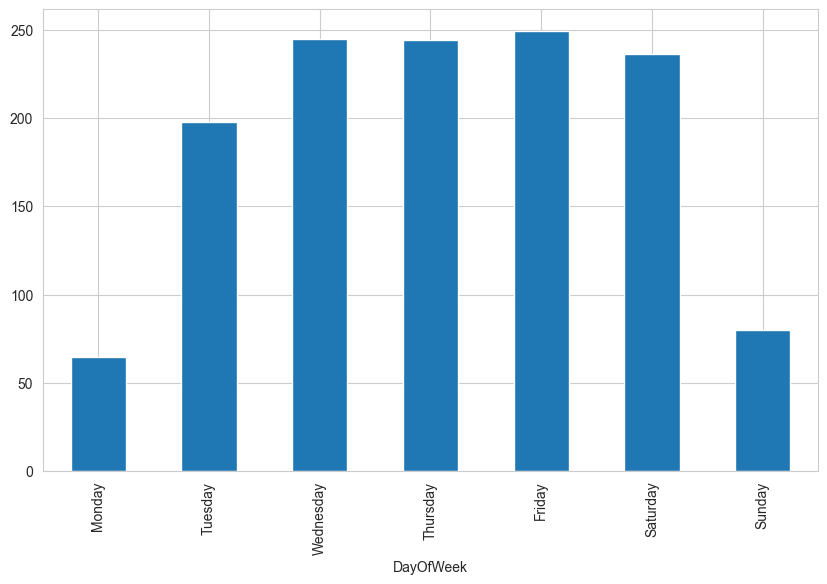

In [ ]:
# Accidents per year
accidents_per_year = london_df['Year'].value_counts().sort_index()
accidents_per_month = london_df['Month'].value_counts().sort_index()
accidents_per_day = london_df['DayOfWeek'].value_counts().sort_index()


#PER YEAR
accidents_per_year.plot(kind='bar')
plt.title('Accidents per Year')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.show()

month_names = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}

# Replace numerical months with their names
accidents_per_month.index = accidents_per_month.index.map(month_names)


accidents_per_month.plot(kind='bar')
plt.title('Accidents per Month')
plt.xlabel('Month')
plt.ylabel('Number of Accidents')
plt.show()


#accident per day
day_names = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}

accidents_per_day.index = accidents_per_day.index.map(day_names)
accidents_per_day.plot(kind='bar')
print(accidents_per_day)

<h4><i>Accident Severity in London</i></h4>

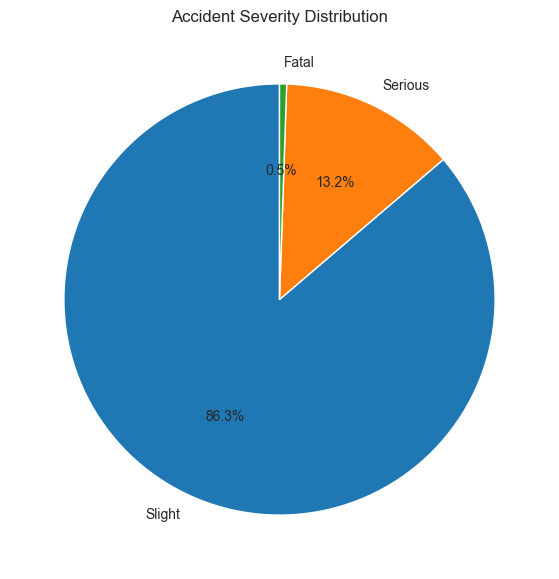

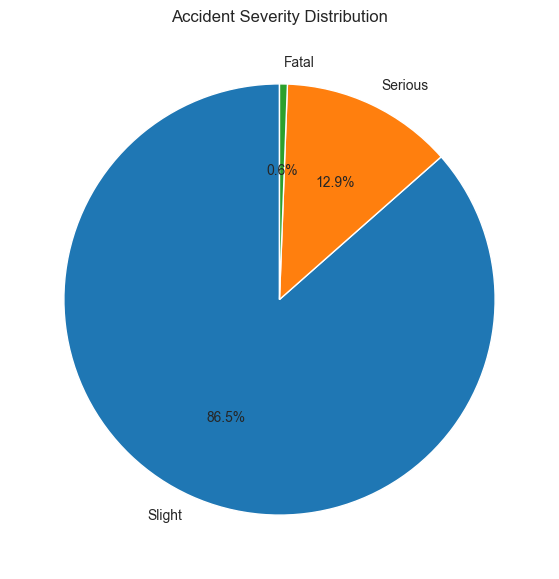

In [ ]:
severity_london  = london_df['Accident_Severity'].value_counts()

plt.pie(severity_london,
        labels = severity_london.index,
        autopct = '%1.1f%%',
        startangle = 90)
plt.gcf().set_size_inches(10,7)
plt.title('Accident Severity Distribution')
plt.show()

severity_2019_london = london_df[london_df['Year'] == 2019]
# severity_2019
lsc_2019 = severity_2019_london['Accident_Severity'].value_counts()

plt.pie(lsc_2019,
        labels = lsc_2019.index,
        autopct = '%1.1f%%',
        startangle = 90)
plt.gcf().set_size_inches(10,7)
plt.title('Accident Severity Distribution')
plt.show()


In [ ]:
london_df = df[df['District Area']== 'City of London']

In [ ]:
#london_df.dtypes
london_fatal = london_df[london_df['Accident_Severity'] == 'Fatal']

In [ ]:
import folium
from folium.plugins import HeatMap

locations  = list(zip(london_fatal['Latitude'],london_fatal['Longitude']))

m = folium.Map(location=[london_fatal['Latitude'].mean(), london_fatal['Longitude'].mean()], zoom_start=10)

# Step 3: Add the heatmap layer
HeatMap(locations).add_to(m)

# Step 4: Save or display the map
m.save('accident_heatmap.html')  # Save the map as an HTML file
m  # Display the map in a Jupyter Notebook

In [ ]:
locations

[(51.510978, -0.107581),
 (51.516045, -0.081859),
 (51.510836, -0.093319),
 (51.518081, -0.0799),
 (51.509631, -0.085587),
 (51.517812, -0.107586),
 (51.515808, -0.089364)]

<br>
<br>
<hr>
<br>
<h1>DATA VISUALIZATIONS WITH SEABORN</h1>
<hr>
<br>
<p> Seaborn for Road Safety: Visualizing UK Accident Data
A Beginne Guide to Seabornmns.</p>

# # 🚦 **Seaborn for Road Safety: Visualizing UK Accident Data**
<b> Now that we've covered mastered Matplotlib basics (bar/pie/line charts),
Seaborn is your next step toward **professional-quality visualizations** with less code.
<ul>
    <li>Why Seaborn makes statistical visualization EASIER than Matplotlib</li>
    <li>How to create 5 powerful safety-focused plots in 5 lines of code</li>
    <li>When to use Seaborn vs Matplotlib (they work together!)</li>
    <li>Real insights from UK road accident patterns</li>
</ul>
<strong>**Pro Tip**: Seaborn is built ON TOP of Matplotlib - it's not a replacement!</strong>

<h1>Count Plot </h1>
<hr>
<p>Only require an X argument and then it will count the value based on the data provided</p>

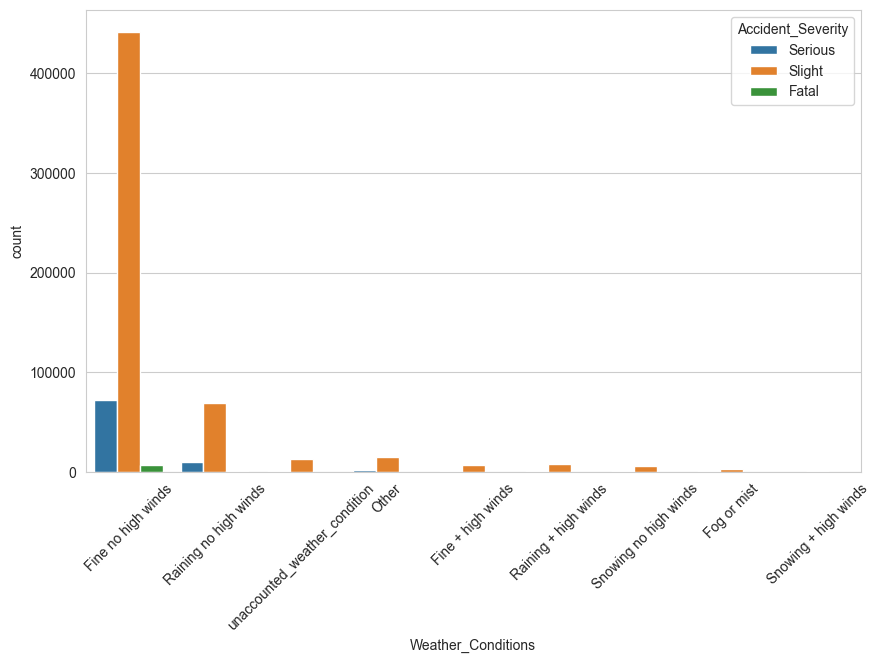

In [ ]:
sns.countplot(
    x='Weather_Conditions',
    hue='Accident_Severity',
    data=df
)
plt.xticks(rotation=45)
plt.show()

<h1> Bar Plot </h1>

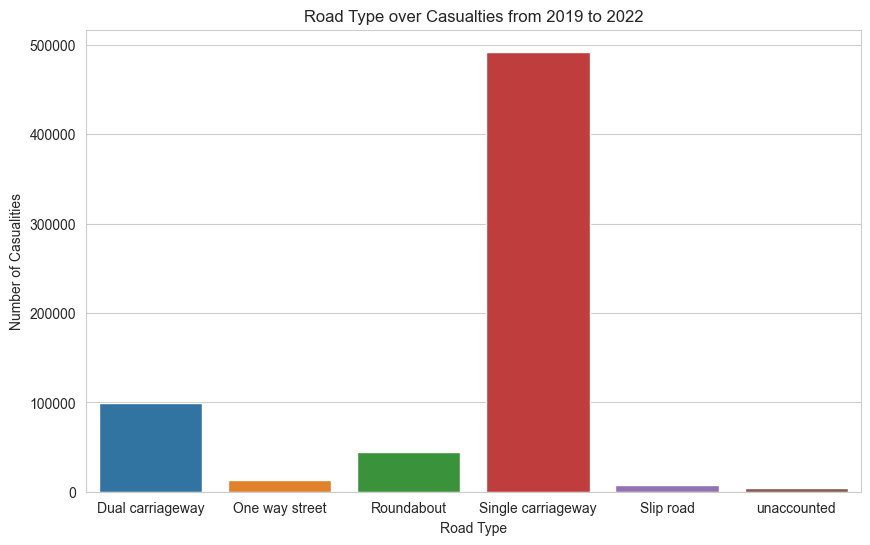

In [ ]:
road_type_casualties = df.groupby(['Road_Type'])['Number_of_Casualties'].size().reset_index()
road_type_casualties

sns.barplot(data=road_type_casualties, x='Road_Type', y='Number_of_Casualties', hue='Road_Type')
plt.xlabel('Road Type')
plt.ylabel('Number of Casualities')
plt.title('Road Type over Casualties from 2019 to 2022')
plt.show()

<h1>Violin Plot </h1>
<h4>Violin Plot and Box Plot are used mainly for checking the average of data</h4>

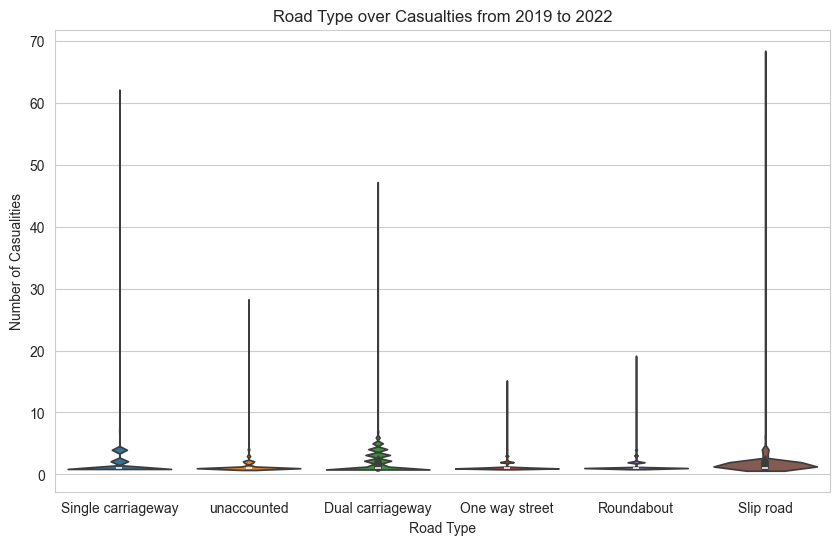

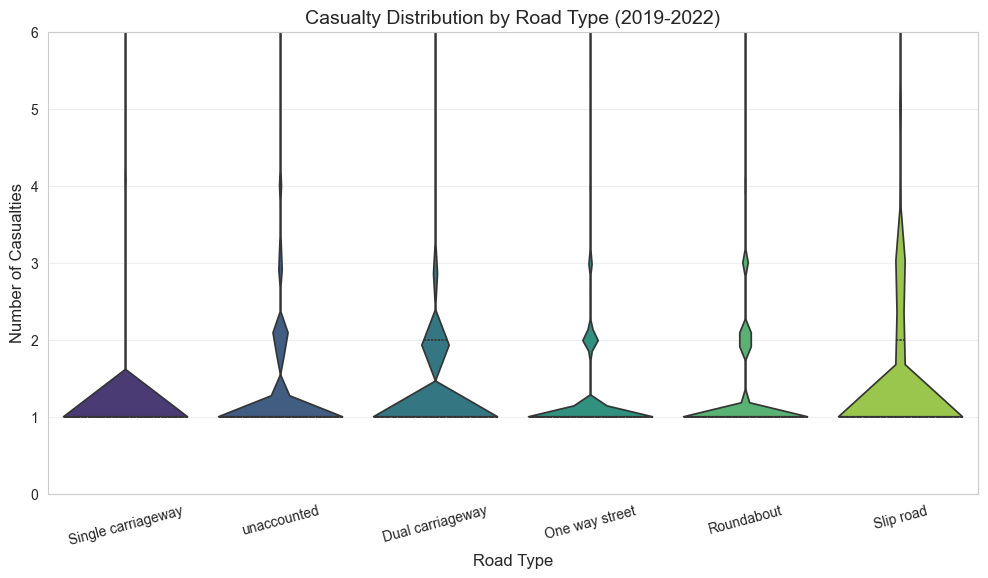

In [ ]:


sns.violinplot(data=df, x='Road_Type', y='Number_of_Casualties', hue='Road_Type')
plt.xlabel('Road Type')
plt.ylabel('Number of Casualities')
plt.title('Road Type over Casualties from 2019 to 2022')
plt.show()


# %% [code]
plt.figure(figsize=(12, 6))

# CORRECTED VIOLIN PLOT (no redundant hue!)
sns.violinplot(
    x='Road_Type',
    y='Number_of_Casualties',
    data=df,
    inner="quart",  # Shows median and IQR (better than full box)
    cut=0,          # Trims to actual data range (critical for skewed data!)
    scale="width",  # Makes all violins same width for fair comparison
    palette="viridis"
)

# ADD THESE CRITICAL FORMATTING LINES:
plt.ylim(0, 6)  # Focus on MOST COMMON range (0-6 casualties)
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)
plt.title('Casualty Distribution by Road Type (2019-2022)', fontsize=14)
plt.xlabel('Road Type', fontsize=12)
plt.ylabel('Number of Casualties', fontsize=12)
plt.show()

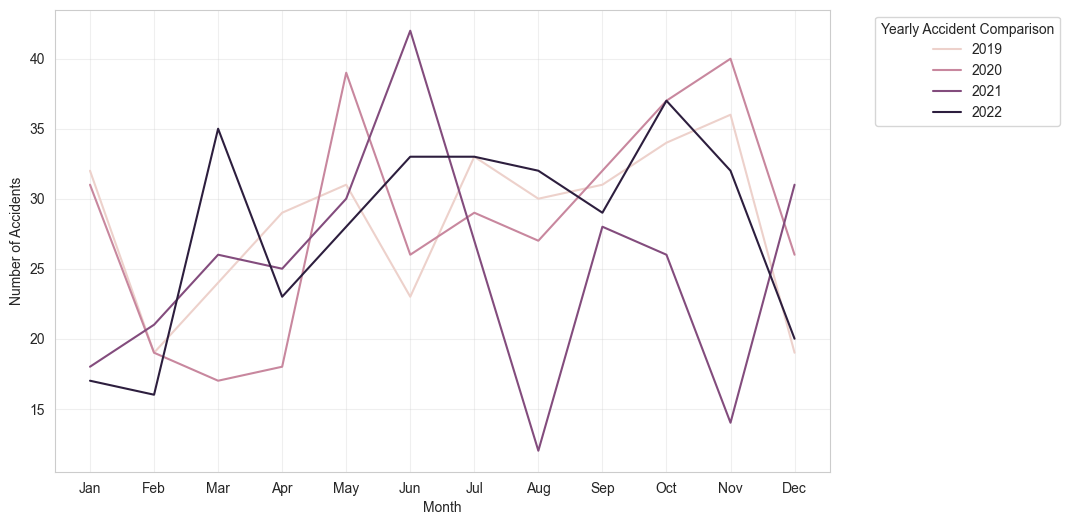

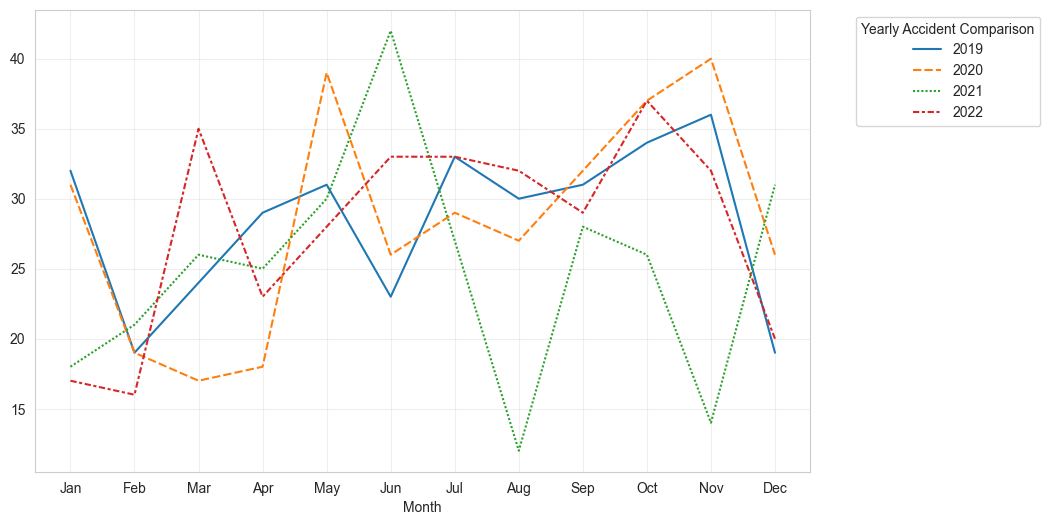

In [ ]:
monthly_londondata = london_df.groupby(['Year', 'Month']).size().reset_index(name = 'Number of Accidents')
monthly_londondata

sns.lineplot(data=monthly_londondata, x = 'Month', y = 'Number of Accidents',hue='Year')

plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend(title='Yearly Accident Comparison', bbox_to_anchor = (1.05,1), loc='upper left')
plt.grid(alpha=0.3)
plt.show()

#another example a shortcut version

mm2 = london_df.groupby(['Year', 'Month']).size().unstack(level=0)
sns.lineplot(data=mm2)

plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend(title='Yearly Accident Comparison', bbox_to_anchor = (1.05,1), loc='upper left')
plt.grid(alpha=0.3)
plt.show()

<h1>Accident Severity vs Vehicle Type in London </h1>

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


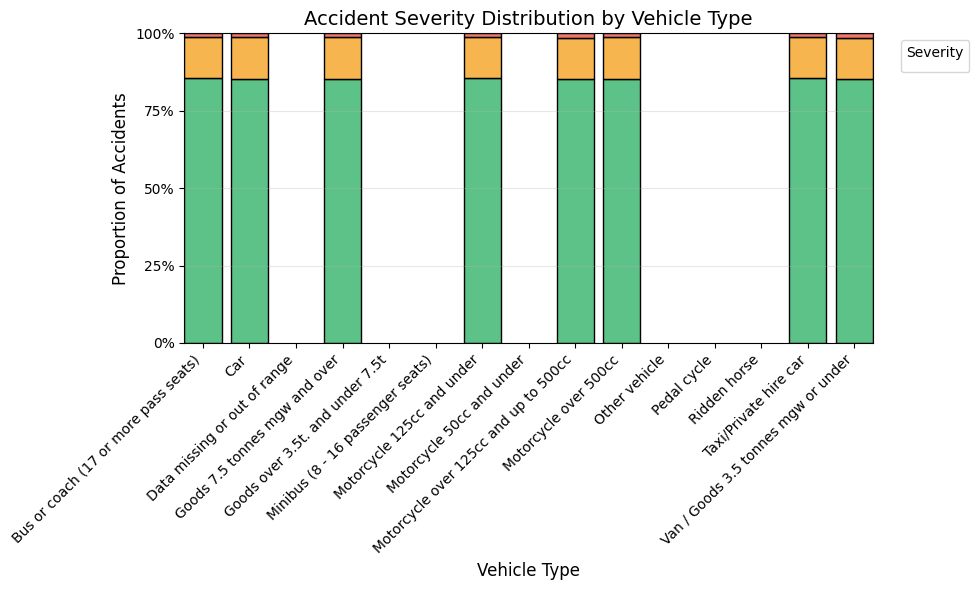

In [ ]:
# %% [code]
# STEP 1: Filter to top 8 vehicle types (CORRECTLY applied)
top_vehicles = df['Vehicle_Type'].value_counts().head(8).index
filtered_df = df[df['Vehicle_Type'].isin(top_vehicles)]  # Save this filtered data

# STEP 2: Create the plot USING THE FILTERED DATA (critical fix!)
plt.figure(figsize=(10, 6))
sns.histplot(
    data=filtered_df,  # ✅ NOW USING filtered_df (NOT df)
    x='Vehicle_Type',
    hue='Accident_Severity',
    multiple='fill',   # Shows percentages within each vehicle type
    palette={'Slight': '#27ae60', 'Serious': '#f39c12', 'Fatal': '#e74c3c'},
    shrink=0.8,
    discrete=True     # Makes bars cleaner for categorical data
)

# STEP 3: Format with BETTER labels
plt.title('Accident Severity Distribution by Vehicle Type', fontsize=14)
plt.xlabel('Vehicle Type', fontsize=12)
plt.ylabel('Proportion of Accidents', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Severity', loc='upper right', bbox_to_anchor=(1.15, 1))  # Moved legend outside

# STEP 4: Add percentage grid lines (student-friendly!)
plt.yticks([0, 0.25, 0.5, 0.75, 1.0], ['0%', '25%', '50%', '75%', '100%'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<h1>Additional Visualizations

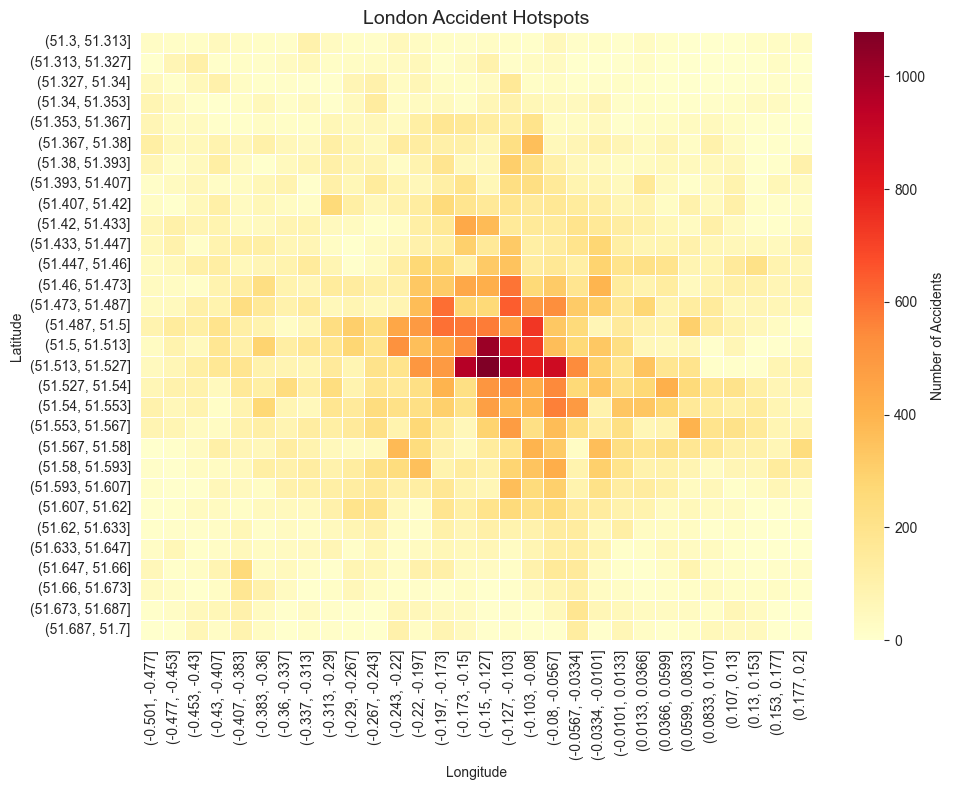

In [ ]:
# Focus on a smaller area for clearer results (London example)
london_df = df[(df['Latitude'] > 51.3) & (df['Latitude'] < 51.7) &
               (df['Longitude'] > -0.5) & (df['Longitude'] < 0.2)]

# Create grid for heatmap
heatmap_data = london_df.groupby(
    [pd.cut(london_df['Latitude'], 30),
     pd.cut(london_df['Longitude'], 30)]
).size().unstack()

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={'label': 'Number of Accidents'}
)

# Add labels
plt.title('London Accident Hotspots', fontsize=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()